Shape: (330961, 2)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 330961 entries, 0 to 330960
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   image   330961 non-null  object
 1   label   330396 non-null  object
dtypes: object(2)
memory usage: 5.1+ MB
None

First 5 rows:
             image      label
0  TRAIN_00001.jpg  BALTHAZAR
1  TRAIN_00002.jpg      SIMON
2  TRAIN_00003.jpg      BENES
3  TRAIN_00004.jpg    LA LOVE
4  TRAIN_00005.jpg     DAPHNE

Missing values per column:
image      0
label    565
dtype: int64


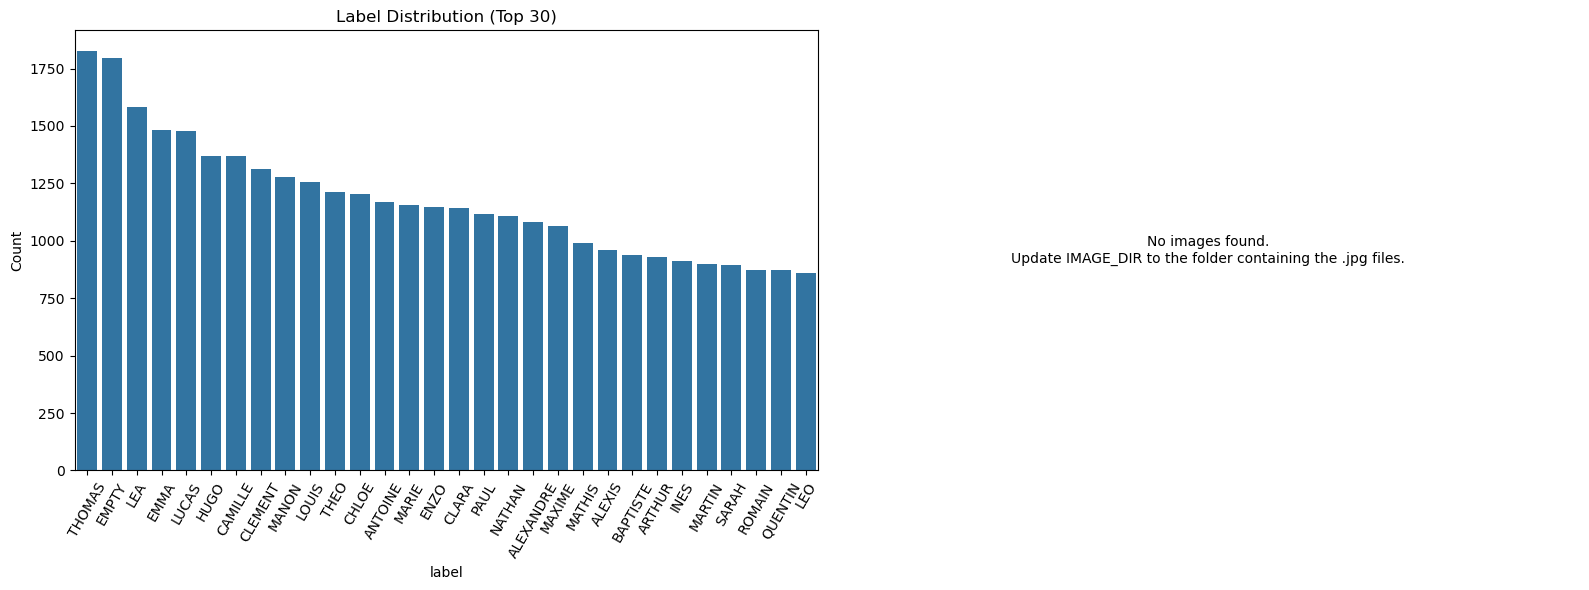

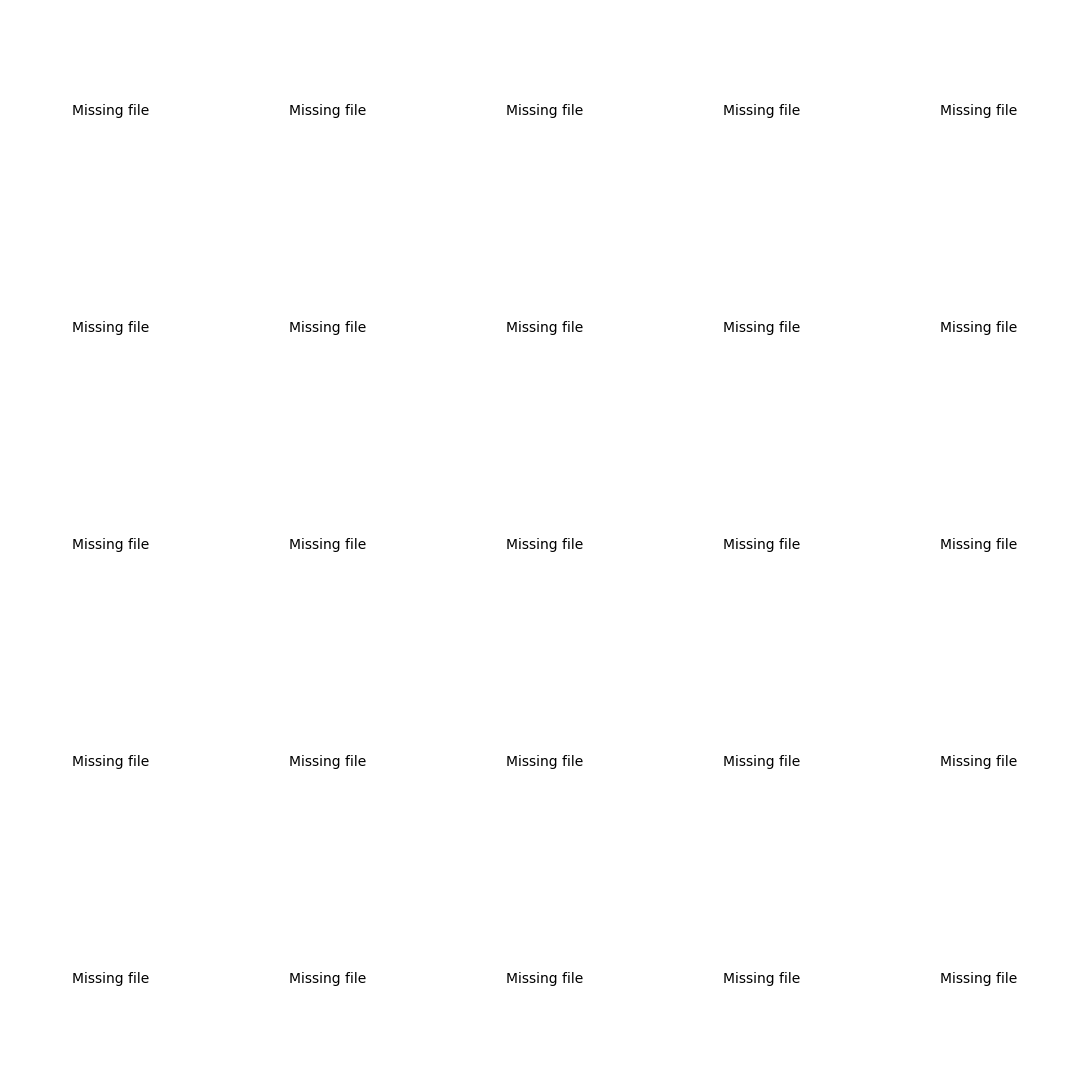

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

CSV_PATH = "written_name_train_v2.csv"

IMAGE_DIR = "Handwriting Recognition_files"

df = pd.read_csv(CSV_PATH)

df = df.rename(columns={"FILENAME": "image", "IDENTITY": "label"})

print("Shape:", df.shape)
print("\nInfo:")
print(df.info())
print("\nFirst 5 rows:")
print(df.head())

print("\nMissing values per column:")
print(df.isnull().sum())

df["label"] = df["label"].astype(str).str.strip()
df = df[df["label"].notna()]


df = df[df["label"].str.upper() != "UNREADABLE"]

TOP_N_LABELS = 30

label_counts = df["label"].value_counts()
top_labels = label_counts.head(TOP_N_LABELS).index

# Sample image dimensions from up to N images
DIM_SAMPLE_N = 200

heights, widths = [], []
sample_paths = df["image"].sample(n=min(DIM_SAMPLE_N, len(df)), random_state=42)

for fname in sample_paths:
    img_full_path = os.path.join(IMAGE_DIR, fname)
    if os.path.exists(img_full_path):
        img = cv2.imread(img_full_path)
        if img is not None:
            h, w = img.shape[:2]
            heights.append(h)
            widths.append(w)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# label distribution (top N)
sns.countplot(
    data=df[df["label"].isin(top_labels)],
    x="label",
    order=top_labels,
    ax=axes[0]
)
axes[0].set_title(f"Label Distribution (Top {TOP_N_LABELS})")
axes[0].set_xlabel("label")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=60)

if len(heights) > 0 and len(widths) > 0:
    sns.histplot(heights, kde=True, label="Heights", ax=axes[1])
    sns.histplot(widths, kde=True, label="Widths", ax=axes[1])
    axes[1].legend()
    axes[1].set_title("Image Dimension Distribution (Sample)")
    axes[1].set_xlabel("Pixels")
    axes[1].set_ylabel("Count")
else:
    axes[1].text(
        0.5, 0.5,
        "No images found.\nUpdate IMAGE_DIR to the folder containing the .jpg files.",
        ha="center", va="center"
    )
    axes[1].axis("off")

plt.tight_layout()
plt.savefig("written_name_overview.png", dpi=200)
plt.show()

def show_samples(df, labels, samples_per_label=5, image_dir=IMAGE_DIR):
    labels = list(labels)
    n_rows = len(labels)
    n_cols = samples_per_label

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2.2, n_rows * 2.2))

    # Make axes always 2D for consistent indexing
    if n_rows == 1:
        axes = [axes]

    for i, label in enumerate(labels):
        subset = df[df["label"] == label]
        if len(subset) == 0:
            for j in range(n_cols):
                axes[i][j].text(0.5, 0.5, f"No rows for: {label}", ha="center", va="center")
                axes[i][j].axis("off")
            continue

        # If subset is smaller than requested samples_per_label, sample what we can
        take_n = min(samples_per_label, len(subset))
        subset = subset.sample(take_n, random_state=42)

        # Fill columns; if fewer than samples_per_label, pad remaining with blanks
        filenames = list(subset["image"].values)
        filenames += [None] * (samples_per_label - len(filenames))

        for j, fname in enumerate(filenames):
            ax = axes[i][j]
            if fname is None:
                ax.axis("off")
                continue

            img_full_path = os.path.join(image_dir, fname)
            if os.path.exists(img_full_path):
                img = cv2.imread(img_full_path, cv2.IMREAD_GRAYSCALE)
                if img is not None:
                    ax.imshow(img, cmap="gray")
                    ax.set_title(str(label), fontsize=9)
                    ax.axis("off")
                else:
                    ax.text(0.5, 0.5, "Unreadable img", ha="center", va="center")
                    ax.axis("off")
            else:
                ax.text(0.5, 0.5, "Missing file", ha="center", va="center")
                ax.axis("off")

    plt.tight_layout()
    plt.show()

# Example: show samples for the top 5 most frequent labels
example_labels = df["label"].value_counts().head(5).index
show_samples(df, example_labels, samples_per_label=5, image_dir=IMAGE_DIR)
